# 验证 GraphCast 低分辨率数据集

这个 notebook 自包含地完成以下工作：

1. 校验待验证数据集与参考 GraphCast 样本的格式是否一致。
2. 运行一次最小 `GraphCast_small` 前向推理。
3. 提取后续真实 target，导出预测值、真实值和差值。
4. 绘制真实值 / 预测值 / 差值三联热力图。

其中真实值与预测值热力图会强制使用相同的时间切片和相同的颜色标尺，`diff` 图使用以 0 为中心的对称标尺。

建议在 `GraphCast` conda 环境中运行。

In [10]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

PROJECT_ROOT = Path("/root/code/gnn-vis/GraphCast/weather-analysis/typhoon-impact-physics-analysis")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REFERENCE_DATASET_PATH = Path(
    "/root/data/dataset/dataset-source-era5_date-2022-01-01_res-1.0_levels-13_steps-04.nc"
)
LOW_RES_PARAMS_PATH = Path(
    "/root/data/params/"
    "params-GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 "
    "- mesh 2to5 - precipitation input and output.npz"
)
STATS_DIR = Path("/root/data/stats")
CANDIDATE_DATASET_PATH = Path(
    "/root/autodl-tmp/dataset/"
    "dataset-source-era5_date-2021-05-16_res-1.0_levels-13_steps-04.nc"
)
EXPORT_DIR = Path("/root/autodl-tmp/dataset/graphcast_validation_2021-05-16")

print(f"参考数据集: {REFERENCE_DATASET_PATH}")
print(f"待验证数据集: {CANDIDATE_DATASET_PATH}")
print(f"参数文件: {LOW_RES_PARAMS_PATH}")
print(f"统计目录: {STATS_DIR}")
print(f"导出目录: {EXPORT_DIR}")


def load_netcdf_dataset(path: Path) -> xr.Dataset:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        try:
            return xr.open_dataset(path, engine="netcdf4").load()
        except Exception:
            return xr.open_dataset(path).load()


def open_dataset(path: Path) -> xr.Dataset:
    return load_netcdf_dataset(path)


def dataset_layout_summary(ds: xr.Dataset) -> dict[str, object]:
    return {
        "sizes": dict(ds.sizes),
        "coords": {
            name: {
                "dims": tuple(ds.coords[name].dims),
                "dtype": str(ds.coords[name].dtype),
                "shape": tuple(ds.coords[name].shape),
            }
            for name in ds.coords
        },
        "data_vars": {
            name: {
                "dims": tuple(ds[name].dims),
                "dtype": str(ds[name].dtype),
                "shape": tuple(ds[name].shape),
            }
            for name in ds.data_vars
        },
    }


def _layout_frame(summary: dict[str, object], kind: str) -> pd.DataFrame:
    rows = []
    for name, info in summary[kind].items():
        rows.append(
            {
                "name": name,
                "dims": info["dims"],
                "shape": info["shape"],
                "dtype": info["dtype"],
            }
        )
    return pd.DataFrame(rows).sort_values("name").reset_index(drop=True)


def _check_datetime_spacing(values: np.ndarray) -> bool:
    flat = np.asarray(values).reshape(-1)
    if flat.size < 2:
        return True
    return np.all(np.diff(flat) == np.timedelta64(6, "h"))


def compare_dataset_layout(candidate: xr.Dataset, reference: xr.Dataset) -> list[str]:
    issues: list[str] = []

    if dict(candidate.sizes) != dict(reference.sizes):
        issues.append(
            f"sizes differ: candidate={dict(candidate.sizes)}, reference={dict(reference.sizes)}"
        )

    candidate_coords = set(candidate.coords)
    reference_coords = set(reference.coords)
    if candidate_coords != reference_coords:
        issues.append(
            f"coords differ: candidate={sorted(candidate_coords)}, reference={sorted(reference_coords)}"
        )

    candidate_vars = set(candidate.data_vars)
    reference_vars = set(reference.data_vars)
    if candidate_vars != reference_vars:
        issues.append(
            f"data_vars differ: candidate={sorted(candidate_vars)}, reference={sorted(reference_vars)}"
        )

    for coord_name in sorted(candidate_coords & reference_coords):
        cand = candidate.coords[coord_name]
        ref = reference.coords[coord_name]

        if tuple(cand.dims) != tuple(ref.dims):
            issues.append(
                f"coord {coord_name} dims differ: candidate={cand.dims}, reference={ref.dims}"
            )
        if tuple(cand.shape) != tuple(ref.shape):
            issues.append(
                f"coord {coord_name} shape differ: candidate={cand.shape}, reference={ref.shape}"
            )

        if coord_name == "datetime":
            if np.asarray(cand.values).dtype.kind != "M":
                issues.append(f"coord datetime dtype is not datetime64: {cand.dtype}")
            if not _check_datetime_spacing(cand.values):
                issues.append("coord datetime does not have 6-hour cadence")
            if not _check_datetime_spacing(ref.values):
                issues.append("reference coord datetime does not have 6-hour cadence")
            continue

        if not np.array_equal(cand.values, ref.values):
            issues.append(f"coord {coord_name} values differ from reference")

    for var_name in sorted(candidate_vars & reference_vars):
        cand = candidate[var_name]
        ref = reference[var_name]
        if tuple(cand.dims) != tuple(ref.dims):
            issues.append(
                f"var {var_name} dims differ: candidate={cand.dims}, reference={ref.dims}"
            )
        if tuple(cand.shape) != tuple(ref.shape):
            issues.append(
                f"var {var_name} shape differ: candidate={cand.shape}, reference={ref.shape}"
            )
        if cand.dtype != ref.dtype:
            issues.append(
                f"var {var_name} dtype differ: candidate={cand.dtype}, reference={ref.dtype}"
            )

    return issues


def _build_graphcast_prediction_bundle(
    dataset_path: Path,
    *,
    params_path: Path,
    stats_dir: Path,
) -> dict[str, object]:
    import jax

    from shared.model_utils import build_run_forward, extract_eval_data, load_checkpoint

    ckpt = load_checkpoint(str(params_path))
    example_batch = load_netcdf_dataset(dataset_path)
    eval_inputs, eval_targets, eval_forcings = extract_eval_data(example_batch, ckpt.task_config)
    diffs_stddev_by_level = load_netcdf_dataset(stats_dir / "stats-diffs_stddev_by_level.nc")
    mean_by_level = load_netcdf_dataset(stats_dir / "stats-mean_by_level.nc")
    stddev_by_level = load_netcdf_dataset(stats_dir / "stats-stddev_by_level.nc")

    run_forward_jitted = build_run_forward(
        ckpt.model_config,
        ckpt.task_config,
        ckpt.params,
        {},
        diffs_stddev_by_level,
        mean_by_level,
        stddev_by_level,
    )

    targets_template = eval_targets * np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        outputs = run_forward_jitted(
            rng=jax.random.PRNGKey(0),
            inputs=eval_inputs,
            targets_template=targets_template,
            forcings=eval_forcings,
        )

    return {
        "ckpt": ckpt,
        "example_batch": example_batch,
        "eval_inputs": eval_inputs,
        "eval_targets": eval_targets,
        "eval_forcings": eval_forcings,
        "outputs": outputs,
    }


def run_graphcast_minimal(
    dataset_path: Path,
    *,
    params_path: Path,
    stats_dir: Path,
) -> dict[str, object]:
    bundle = _build_graphcast_prediction_bundle(
        dataset_path,
        params_path=params_path,
        stats_dir=stats_dir,
    )
    outputs = bundle["outputs"]
    ckpt = bundle["ckpt"]

    output_vars = tuple(outputs.data_vars)
    expected_vars = tuple(ckpt.task_config.target_variables)
    if set(output_vars) != set(expected_vars):
        raise ValueError(
            f"Unexpected GraphCast outputs: got {output_vars}, expected {expected_vars}"
        )

    sample_var = outputs[output_vars[0]]
    sample_value = float(np.asarray(sample_var.isel(batch=0, time=0).values).reshape(-1)[0])
    if not np.isfinite(sample_value):
        raise ValueError(f"Non-finite sample value from GraphCast output: {sample_value}")

    return {
        "output_sizes": dict(outputs.sizes),
        "output_vars": output_vars,
        "sample_var": output_vars[0],
        "sample_value": sample_value,
    }


def _compute_error_metrics(prediction: np.ndarray, target: np.ndarray) -> dict[str, float]:
    pred = np.asarray(prediction, dtype=np.float64)
    truth = np.asarray(target, dtype=np.float64)
    diff = pred - truth
    return {
        "rmse": float(np.sqrt(np.nanmean(diff ** 2))),
        "mae": float(np.nanmean(np.abs(diff))),
        "bias": float(np.nanmean(diff)),
        "max_abs": float(np.nanmax(np.abs(diff))),
    }


def extract_target_datetime_coord(
    example_batch: xr.Dataset,
    eval_targets: xr.Dataset,
) -> xr.DataArray | None:
    if "datetime" in eval_targets.coords:
        return eval_targets["datetime"]

    if "datetime" not in example_batch.coords:
        return None
    if "time" not in example_batch.coords or "time" not in eval_targets.coords:
        return None

    source_times = np.asarray(example_batch["time"].values)
    target_times = np.asarray(eval_targets["time"].values)
    time_indices: list[int] = []
    for target_time in target_times:
        matches = np.where(source_times == target_time)[0]
        if matches.size != 1:
            return None
        time_indices.append(int(matches[0]))

    return example_batch["datetime"].isel(time=time_indices)


def build_prediction_comparison_datasets(
    outputs: xr.Dataset,
    eval_targets: xr.Dataset,
) -> tuple[xr.Dataset, xr.Dataset]:
    prediction_vars: dict[str, xr.DataArray] = {}
    error_vars: dict[str, xr.DataArray] = {}

    for var_name in eval_targets.data_vars:
        target = eval_targets[var_name]
        prediction = outputs[var_name].transpose(*target.dims)
        aligned_prediction = xr.DataArray(
            prediction.values,
            dims=target.dims,
            coords=target.coords,
            attrs=dict(target.attrs),
        )
        prediction_vars[var_name] = aligned_prediction
        error_vars[var_name] = xr.DataArray(
            (aligned_prediction - target).values,
            dims=target.dims,
            coords=target.coords,
            attrs={
                "long_name": f"{var_name} prediction minus truth",
                "description": "GraphCast prediction minus extracted ERA5 ground truth",
            },
        )

    predictions = xr.Dataset(prediction_vars, coords=eval_targets.coords)
    errors = xr.Dataset(error_vars, coords=eval_targets.coords)
    predictions.attrs = {
        "description": "GraphCast predictions aligned to the extracted target coordinates"
    }
    errors.attrs = {
        "description": "GraphCast prediction minus extracted ERA5 ground truth"
    }
    return predictions, errors


def compare_graphcast_predictions(
    dataset_path: Path,
    *,
    params_path: Path,
    stats_dir: Path,
) -> dict[str, object]:
    bundle = _build_graphcast_prediction_bundle(
        dataset_path,
        params_path=params_path,
        stats_dir=stats_dir,
    )
    outputs = bundle["outputs"]
    eval_targets = bundle["eval_targets"]
    target_datetime_coord = extract_target_datetime_coord(bundle["example_batch"], eval_targets)
    if target_datetime_coord is not None:
        eval_targets = eval_targets.assign_coords(datetime=target_datetime_coord)
    predictions, errors = build_prediction_comparison_datasets(outputs, eval_targets)

    overall: list[dict[str, object]] = []
    by_time: list[dict[str, object]] = []

    for var_name in eval_targets.data_vars:
        target = eval_targets[var_name]
        prediction = predictions[var_name]
        metrics = _compute_error_metrics(prediction.values, target.values)
        overall.append({"variable": var_name, **metrics})

        if "time" in target.dims:
            for time_idx in range(target.sizes["time"]):
                time_pred = prediction.isel(time=time_idx)
                time_target = target.isel(time=time_idx)
                time_metrics = _compute_error_metrics(time_pred.values, time_target.values)
                by_time.append(
                    {
                        "variable": var_name,
                        "time_idx": int(time_idx),
                        "lead_time": str(target["time"].values[time_idx]),
                        **time_metrics,
                    }
                )

    return {
        "overall": overall,
        "by_time": by_time,
        "outputs": outputs,
        "predictions": predictions,
        "targets": eval_targets,
        "errors": errors,
    }


def export_prediction_comparison(summary: dict[str, object], output_dir: Path) -> dict[str, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)

    predictions_path = output_dir / "graphcast_predictions.nc"
    targets_path = output_dir / "graphcast_truth_targets.nc"
    errors_path = output_dir / "graphcast_prediction_minus_truth.nc"
    metrics_path = output_dir / "graphcast_prediction_metrics.json"

    summary["predictions"].to_netcdf(predictions_path)
    summary["targets"].to_netcdf(targets_path)
    summary["errors"].to_netcdf(errors_path)

    metrics_payload = {
        "overall": summary["overall"],
        "by_time": summary["by_time"],
        "target_variables": list(summary["targets"].data_vars),
        "lead_times": [str(value) for value in summary["targets"]["time"].values],
    }
    if "datetime" in summary["targets"].coords:
        metrics_payload["target_datetimes"] = [
            [str(value) for value in row]
            for row in np.asarray(summary["targets"]["datetime"].values)
        ]
    metrics_path.write_text(
        json.dumps(metrics_payload, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

    return {
        "predictions": predictions_path,
        "targets": targets_path,
        "errors": errors_path,
        "metrics": metrics_path,
    }


def select_heatmap_slice(
    dataset: xr.Dataset,
    *,
    variable: str,
    time_idx: int,
    level: int | None = None,
) -> xr.DataArray:
    if variable not in dataset.data_vars:
        raise ValueError(
            f"Variable {variable!r} not found. Available variables: {sorted(dataset.data_vars)}"
        )

    field = dataset[variable]
    if "batch" in field.dims:
        field = field.isel(batch=0)

    if "time" not in field.dims:
        raise ValueError(f"Variable {variable!r} has no time dimension.")
    if time_idx < 0 or time_idx >= field.sizes["time"]:
        raise ValueError(
            f"time_idx={time_idx} is out of range for variable {variable!r}; "
            f"valid range is [0, {field.sizes['time'] - 1}]"
        )
    field = field.isel(time=time_idx)

    if "level" in field.dims:
        if level is None:
            raise ValueError(
                f"变量 {variable!r} 含有 level 维，请设置 level，例如 500。"
            )
        available_levels = np.asarray(dataset["level"].values)
        if level not in set(np.asarray(available_levels).tolist()):
            raise ValueError(
                f"Level {level} 不在可用层次中，可选值: {available_levels.tolist()}"
            )
        field = field.sel(level=level)
    elif level is not None:
        raise ValueError(f"变量 {variable!r} 不含 level 维，不应设置 level。")

    if tuple(field.dims) != ("lat", "lon"):
        raise ValueError(
            f"绘图需要二维 lat/lon 切片，当前得到的维度是 {field.dims}。"
        )
    return field


def plot_prediction_heatmaps(
    summary: dict[str, object],
    output_dir: Path,
    *,
    variable: str,
    time_idx: int,
    level: int | None = None,
) -> Path:
    import matplotlib.pyplot as plt
    from matplotlib.colors import Normalize, TwoSlopeNorm

    predictions = summary["predictions"]
    targets = summary["targets"]
    errors = summary["errors"]

    truth_slice = select_heatmap_slice(targets, variable=variable, time_idx=time_idx, level=level)
    prediction_slice = select_heatmap_slice(predictions, variable=variable, time_idx=time_idx, level=level)
    diff_slice = select_heatmap_slice(errors, variable=variable, time_idx=time_idx, level=level)

    shared_min = float(min(np.nanmin(truth_slice.values), np.nanmin(prediction_slice.values)))
    shared_max = float(max(np.nanmax(truth_slice.values), np.nanmax(prediction_slice.values)))
    if np.isclose(shared_min, shared_max):
        shared_max = shared_min + 1e-6

    diff_abs = float(np.nanmax(np.abs(diff_slice.values)))
    if np.isclose(diff_abs, 0.0):
        diff_abs = 1e-6

    main_norm = Normalize(vmin=shared_min, vmax=shared_max)
    diff_norm = TwoSlopeNorm(vmin=-diff_abs, vcenter=0.0, vmax=diff_abs)
    lat = truth_slice["lat"].values
    lon = truth_slice["lon"].values

    time_label = str(targets["time"].values[time_idx])
    if "datetime" in targets.coords:
        time_label = str(targets["datetime"].isel(batch=0, time=time_idx).values)

    level_suffix = f", level={level}" if level is not None else ""
    units = truth_slice.attrs.get("units")
    units_suffix = f" [{units}]" if units else ""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    truth_mesh = axes[0].pcolormesh(
        lon,
        lat,
        truth_slice.values,
        shading="auto",
        cmap="viridis",
        norm=main_norm,
    )
    pred_mesh = axes[1].pcolormesh(
        lon,
        lat,
        prediction_slice.values,
        shading="auto",
        cmap="viridis",
        norm=main_norm,
    )
    diff_mesh = axes[2].pcolormesh(
        lon,
        lat,
        diff_slice.values,
        shading="auto",
        cmap="coolwarm",
        norm=diff_norm,
    )

    axes[0].set_title("真实值")
    axes[1].set_title("预测值")
    axes[2].set_title("预测值 - 真实值")
    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    colorbar_main = fig.colorbar(pred_mesh, ax=axes[:2], location="right", shrink=0.9, pad=0.02)
    colorbar_main.set_label(f"{variable}{units_suffix}")
    colorbar_diff = fig.colorbar(diff_mesh, ax=axes[2], location="right", shrink=0.9, pad=0.02)
    colorbar_diff.set_label(f"{variable} diff{units_suffix}")

    fig.suptitle(
        f"{variable}{level_suffix}, time={time_label}, shared_scale=[{shared_min:.3f}, {shared_max:.3f}]",
        fontsize=12,
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    level_part = f"_level-{level}" if level is not None else ""
    plot_path = output_dir / f"graphcast_heatmaps_{variable}_time-{time_idx}{level_part}.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return plot_path


参考数据集: /root/data/dataset/dataset-source-era5_date-2022-01-01_res-1.0_levels-13_steps-04.nc
待验证数据集: /root/autodl-tmp/dataset/dataset-source-era5_date-2021-05-16_res-1.0_levels-13_steps-04.nc
参数文件: /root/data/params/params-GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz
统计目录: /root/data/stats
导出目录: /root/autodl-tmp/dataset/graphcast_validation_2021-05-16


In [11]:
reference = open_dataset(REFERENCE_DATASET_PATH)
candidate = open_dataset(CANDIDATE_DATASET_PATH)

candidate_summary = dataset_layout_summary(candidate)
reference_summary = dataset_layout_summary(reference)

print("待验证数据集维度:", candidate_summary["sizes"])
display(_layout_frame(candidate_summary, "coords"))
display(_layout_frame(candidate_summary, "data_vars"))

issues = compare_dataset_layout(candidate, reference)
if issues:
    print("格式校验失败:")
    for issue in issues:
        print(f"- {issue}")
else:
    print("格式校验通过：待验证数据集与参考 GraphCast 数据集格式一致。")

datetime_table = pd.DataFrame(
    {
        "待验证绝对时间": candidate["datetime"].values[0],
        "参考绝对时间": reference["datetime"].values[0],
        "相对时间": candidate["time"].values,
    }
)
display(datetime_table)

# 预览几个关键变量，确认数据值和维度正常。
display(candidate["mean_sea_level_pressure"].isel(batch=0, time=0))
display(candidate["2m_temperature"].isel(batch=0, time=0))
display(candidate["temperature"].isel(batch=0, time=0, level=7))


待验证数据集维度: {'lat': 181, 'lon': 360, 'batch': 1, 'time': 6, 'level': 13}


,name,dims,shape,dtype
0,datetime,"(batch, time)","(1, 6)",datetime64[ns]
1,lat,"(lat,)","(181,)",float32
2,level,"(level,)","(13,)",int32
3,lon,"(lon,)","(360,)",float32
4,time,"(time,)","(6,)",timedelta64[ns]


,name,dims,shape,dtype
0,10m_u_component_of_wind,"(batch, time, lat, lon)","(1, 6, 181, 360)",float32
1,10m_v_component_of_wind,"(batch, time, lat, lon)","(1, 6, 181, 360)",float32
2,2m_temperature,"(batch, time, lat, lon)","(1, 6, 181, 360)",float32
3,geopotential,"(batch, time, level, lat, lon)","(1, 6, 13, 181, 360)",float32
4,geopotential_at_surface,"(lat, lon)","(181, 360)",float32
5,land_sea_mask,"(lat, lon)","(181, 360)",float32
6,mean_sea_level_pressure,"(batch, time, lat, lon)","(1, 6, 181, 360)",float32
7,specific_humidity,"(batch, time, level, lat, lon)","(1, 6, 13, 181, 360)",float32
8,temperature,"(batch, time, level, lat, lon)","(1, 6, 13, 181, 360)",float32
9,toa_incident_solar_radiation,"(batch, time, lat, lon)","(1, 6, 181, 360)",float32


格式校验通过：待验证数据集与参考 GraphCast 数据集格式一致。


,待验证绝对时间,参考绝对时间,相对时间
0,2021-05-16 00:00:00,2022-01-01 00:00:00,0 days 00:00:00
1,2021-05-16 06:00:00,2022-01-01 06:00:00,0 days 06:00:00
2,2021-05-16 12:00:00,2022-01-01 12:00:00,0 days 12:00:00
3,2021-05-16 18:00:00,2022-01-01 18:00:00,0 days 18:00:00
4,2021-05-17 00:00:00,2022-01-02 00:00:00,1 days 00:00:00
5,2021-05-17 06:00:00,2022-01-02 06:00:00,1 days 06:00:00


<xarray.DataArray 'mean_sea_level_pressure' (lat: 181, lon: 360)> Size: 261kB
array([[100849.58 , 100851.11 , 100852.09 , ..., 100843.24 , 100845.266,
        100847.305],
       [100710.68 , 100721.66 , 100732.805, ..., 100680.92 , 100690.69 ,
        100700.54 ],
       [100499.68 , 100516.16 , 100531.016, ..., 100444.17 , 100461.71 ,
        100480.25 ],
       ...,
       [101496.66 , 101492.19 , 101487.72 , ..., 101509.17 , 101505.19 ,
        101500.96 ],
       [101432.74 , 101431.96 , 101431.29 , ..., 101435.72 , 101434.72 ,
        101433.72 ],
       [101419.375, 101419.46 , 101419.516, ..., 101419.14 , 101419.19 ,
        101419.305]], dtype=float32)
Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    time      timedelta64[ns] 8B 00:00:00
    datetime  datetime64[ns] 8B 2021-05-16

<xarray.DataArray '2m_temperature' (lat: 181, lon: 360)> Size: 261kB
array([[228.83405, 228.82971, 228.82613, ..., 228.83987, 228.83875,
        228.83664],
       [230.76988, 230.7244 , 230.67659, ..., 230.88542, 230.84813,
        230.81029],
       [233.40082, 233.27884, 233.16466, ..., 233.66254, 233.58212,
        233.49774],
       ...,
       [266.85168, 266.87076, 266.8886 , ..., 266.77524, 266.79913,
        266.82544],
       [267.2247 , 267.20847, 267.18976, ..., 267.2286 , 267.22763,
        267.22748],
       [266.91934, 266.90894, 266.8967 , ..., 266.95105, 266.94095,
        266.93005]], dtype=float32)
Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    time      timedelta64[ns] 8B 00:00:00
    datetime  datetime64[ns] 8B 2021-05-16

<xarray.DataArray 'temperature' (lat: 181, lon: 360)> Size: 261kB
array([[229.64365, 229.63762, 229.63162, ..., 229.6617 , 229.65558,
        229.64973],
       [229.79366, 229.76604, 229.73868, ..., 229.87808, 229.84978,
        229.82155],
       [229.94232, 229.88966, 229.8388 , ..., 230.11192, 230.05345,
        229.99702],
       ...,
       [240.48935, 240.4705 , 240.45085, ..., 240.53969, 240.52385,
        240.50706],
       [240.28812, 240.27641, 240.2649 , ..., 240.32256, 240.31116,
        240.29971],
       [240.21771, 240.21457, 240.2118 , ..., 240.22646, 240.22366,
        240.22063]], dtype=float32)
Coordinates:
  * lat       (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon       (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    level     int32 4B 500
    time      timedelta64[ns] 8B 00:00:00
    datetime  datetime64[ns] 8B 2021-05-16

## 最小 GraphCast 前向验证

第一次运行会触发 JIT 编译，可能需要一点时间。

In [12]:
run_summary = run_graphcast_minimal(
    CANDIDATE_DATASET_PATH,
    params_path=LOW_RES_PARAMS_PATH,
    stats_dir=STATS_DIR,
)
run_summary


{'output_sizes': {'time': 4, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13},
 'output_vars': ('10m_u_component_of_wind',
  '10m_v_component_of_wind',
  '2m_temperature',
  'geopotential',
  'mean_sea_level_pressure',
  'specific_humidity',
  'temperature',
  'total_precipitation_6hr',
  'u_component_of_wind',
  'v_component_of_wind',
  'vertical_velocity'),
 'sample_var': '10m_u_component_of_wind',
 'sample_value': -2.041572332382202}

## 真实值、预测值与热力图

下面这一步会同时导出三份对齐后的数据文件：

- `graphcast_truth_targets.nc`
- `graphcast_predictions.nc`
- `graphcast_prediction_minus_truth.nc`

然后再绘制三联热力图。默认示例画的是 `2m_temperature` 在第 0 个目标时次的结果。

导出的对齐结果文件:
- predictions: /root/autodl-tmp/dataset/graphcast_validation_2021-05-16/graphcast_predictions.nc
- targets: /root/autodl-tmp/dataset/graphcast_validation_2021-05-16/graphcast_truth_targets.nc
- errors: /root/autodl-tmp/dataset/graphcast_validation_2021-05-16/graphcast_prediction_minus_truth.nc
- metrics: /root/autodl-tmp/dataset/graphcast_validation_2021-05-16/graphcast_prediction_metrics.json


,variable,rmse,mae,bias,max_abs
0,10m_u_component_of_wind,0.841651,0.551385,-0.010000,14.186335
1,10m_v_component_of_wind,0.870475,0.571998,-0.005184,18.010085
2,2m_temperature,0.655899,0.426321,-0.041909,5.975418
3,geopotential,47.229983,34.601817,-1.714097,747.920898
4,mean_sea_level_pressure,63.604599,42.249803,-3.409167,861.601562
5,specific_humidity,0.000263,0.000109,0.000002,0.010072
6,temperature,0.524836,0.370601,0.008620,7.157349
7,total_precipitation_6hr,0.000886,0.000264,0.000074,0.053834
8,u_component_of_wind,1.546188,1.037392,-0.016106,25.459289
9,v_component_of_wind,1.618433,1.066214,0.004112,40.670021


,variable,time_idx,lead_time,rmse,mae,bias,max_abs
0,10m_u_component_of_wind,0,21600000000000 nanoseconds,0.573838,0.422433,-1.345452e-03,4.688197
1,10m_u_component_of_wind,1,43200000000000 nanoseconds,0.707354,0.494054,-1.821536e-02,9.658694
2,10m_u_component_of_wind,2,64800000000000 nanoseconds,0.935383,0.616028,-5.141838e-03,11.737221
3,10m_u_component_of_wind,3,86400000000000 nanoseconds,1.062510,0.673024,-1.529550e-02,14.186335
4,10m_v_component_of_wind,0,21600000000000 nanoseconds,0.637027,0.449620,-7.676534e-03,6.132998
5,10m_v_component_of_wind,1,43200000000000 nanoseconds,0.819703,0.526578,1.224592e-02,11.555898
6,10m_v_component_of_wind,2,64800000000000 nanoseconds,0.967135,0.639040,-9.424603e-03,9.344556
7,10m_v_component_of_wind,3,86400000000000 nanoseconds,1.008881,0.672752,-1.587923e-02,18.010085
8,2m_temperature,0,21600000000000 nanoseconds,0.526578,0.334168,-2.355714e-02,4.942444
9,2m_temperature,1,43200000000000 nanoseconds,0.631030,0.412828,2.553597e-04,5.351013


/tmp/ipykernel_18082/2877016670.py:534: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_18082/2877016670.py:534: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_18082/2877016670.py:534: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_18082/2877016670.py:534: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")
/tmp/ipykernel_18082/2877016670.py:534: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.savefig(plot_path, dpi=160, bbox_inches="tight")


热力图已保存到: /root/autodl-tmp/dataset/graphcast_validation_2021-05-16/graphcast_heatmaps_2m_temperature_time-0.png


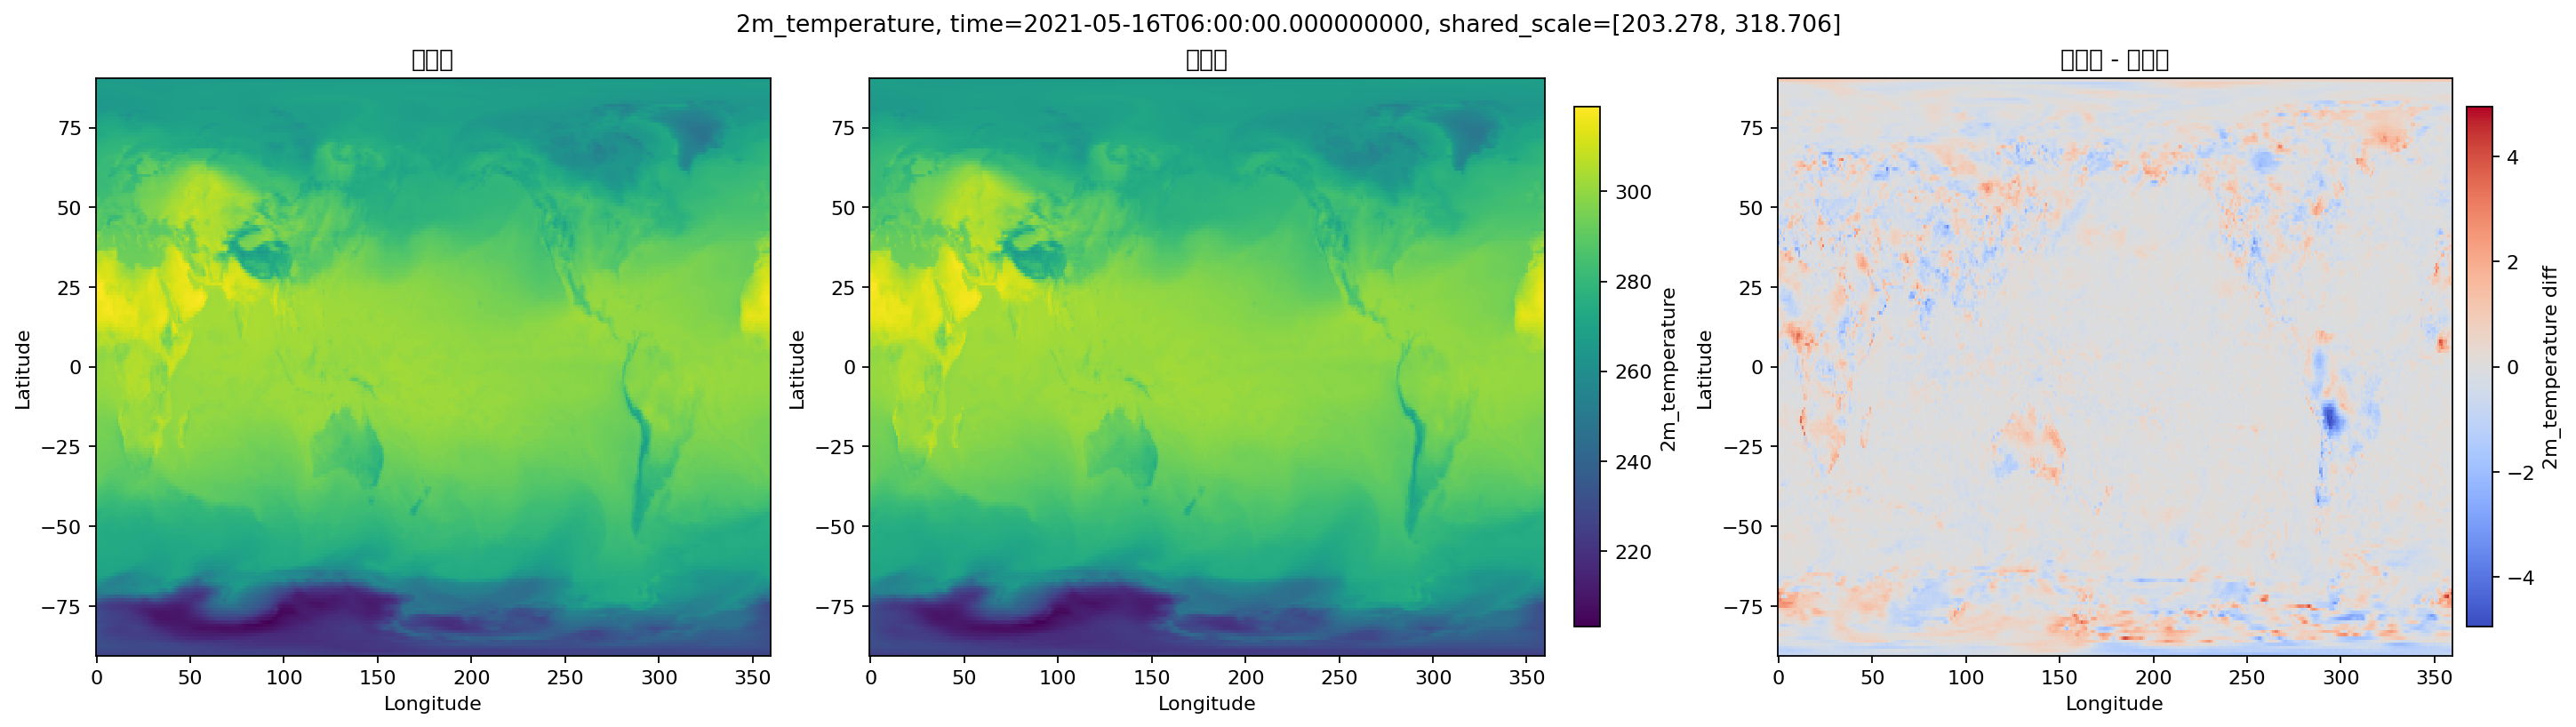

In [13]:
comparison = compare_graphcast_predictions(
    CANDIDATE_DATASET_PATH,
    params_path=LOW_RES_PARAMS_PATH,
    stats_dir=STATS_DIR,
)
exported_paths = export_prediction_comparison(comparison, EXPORT_DIR)

print("导出的对齐结果文件:")
for name, path in exported_paths.items():
    print(f"- {name}: {path}")

overall_metrics = pd.DataFrame(comparison["overall"]).sort_values("variable").reset_index(drop=True)
by_time_metrics = pd.DataFrame(comparison["by_time"]).sort_values(["variable", "time_idx"]).reset_index(drop=True)

display(overall_metrics)
display(by_time_metrics)

# 如果要画高空变量，例如 temperature / u_component_of_wind，需要把 PLOT_LEVEL 改成具体气压层。
PLOT_VARIABLE = "2m_temperature"
PLOT_TIME_IDX = 0
PLOT_LEVEL = None

plot_path = plot_prediction_heatmaps(
    comparison,
    EXPORT_DIR,
    variable=PLOT_VARIABLE,
    time_idx=PLOT_TIME_IDX,
    level=PLOT_LEVEL,
)
print(f"热力图已保存到: {plot_path}")
display(Image(filename=str(plot_path)))
